# 2026-02-11 ~ 2026-05-11 주 단위 모터 개폐율·온도·강우·기상청 일사/일조 분석

## 분석 목표

이 노트북은 기존 `data_inspect_260211-260511.ipynb`와 동일한 센서 데이터를 대상으로, 선택한 **1주 구간**을 자세히 분석한다.

분석에 함께 사용하는 데이터는 다음과 같다.

- 모든 모터 채널의 실제 `open_rate` 개폐율
- 내부온도와 외부온도
- 우적 센서의 `rain` 값
  - `0`: 맑음 또는 비 감지 없음
  - `0`보다 큼: 강우 감지
- `pipeline_output/kma_data` 폴더의 기상청 데이터
  - `SS`: 일조 시간
  - `SI`: 일사량

데이터가 많으므로 전체 기간을 한 번에 자세히 그리지 않고, 중간 설정 변수로 분석할 주를 바꿀 수 있게 구성했다.

## 0. 분석 방법 요약

### 왜 1주 단위로 보는가?

전체 기간은 약 3개월이므로 모든 채널과 기상 변수를 한 그래프에 올리면 해석이 어렵다. 1주 단위로 나누면 다음을 더 쉽게 볼 수 있다.

- 특정 날짜에 모터 개폐율이 급격히 높아졌는가?
- 내부온도 상승과 개폐율 상승이 같은 시간대에 나타나는가?
- 비가 감지된 시간에는 개폐율이 낮아지는가?
- 일사량과 일조 시간이 큰 날에 내부온도와 개폐율이 함께 상승하는가?

### 상관관계 해석 주의

상관계수는 인과관계를 뜻하지 않는다. 예를 들어 개폐율과 일사량의 상관이 높더라도, 실제 제어 원인은 온도, 습도, 강우, 운영 정책, 채널 위치가 함께 작용했을 수 있다. 따라서 이 노트북은 “원인 확정”이 아니라 “검토해야 할 현상 찾기”에 초점을 둔다.

In [28]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, clear_output, display

ANALYSIS_START = "2026-02-11 00:00:00"
ANALYSIS_END = "2026-05-11 17:00:00"
ANALYSIS_TIMEZONE = "Asia/Seoul"
RESAMPLE_RULE = "1h"

current = Path.cwd().resolve()
PROJECT_ROOT = next(
    path
    for path in [current, *current.parents]
    if (path / "pipeline_output" / "organized_by_sensor").exists()
)
ORGANIZED_SENSOR_ROOT = PROJECT_ROOT / "pipeline_output" / "organized_by_sensor"
KMA_CSV_ROOT = PROJECT_ROOT / "pipeline_output" / "kma_data" / "csv"
OUTPUT_ROOT = PROJECT_ROOT / "data_inspect" / "output" / "weekly_motor_weather_analysis_260211-260511"
PLOT_ROOT = OUTPUT_ROOT / "plots"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
PLOT_ROOT.mkdir(parents=True, exist_ok=True)

ANALYSIS_START_TS = pd.Timestamp(ANALYSIS_START, tz="UTC")
ANALYSIS_END_TS = pd.Timestamp(ANALYSIS_END, tz="UTC")
ANALYSIS_START_LOCAL = ANALYSIS_START_TS.tz_convert(ANALYSIS_TIMEZONE)
ANALYSIS_END_LOCAL = ANALYSIS_END_TS.tz_convert(ANALYSIS_TIMEZONE)

plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.unicode_minus"] = False

for font_name in ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]:
    try:
        plt.rcParams["font.family"] = font_name
        break
    except Exception:
        pass

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"ORGANIZED_SENSOR_ROOT = {ORGANIZED_SENSOR_ROOT}")
print(f"KMA_CSV_ROOT = {KMA_CSV_ROOT}")
print(f"OUTPUT_ROOT = {OUTPUT_ROOT}")

PROJECT_ROOT = /Users/jeong-won-il/workspace/SDF/train
ORGANIZED_SENSOR_ROOT = /Users/jeong-won-il/workspace/SDF/train/pipeline_output/organized_by_sensor
KMA_CSV_ROOT = /Users/jeong-won-il/workspace/SDF/train/pipeline_output/kma_data/csv
OUTPUT_ROOT = /Users/jeong-won-il/workspace/SDF/train/data_inspect/output/weekly_motor_weather_analysis_260211-260511


## 1. 주 선택 설정

아래 변수만 바꾸면 분석 대상 주를 쉽게 변경할 수 있다.

- `SELECTED_WEEK_INDEX`: 자동 생성된 주 목록에서 몇 번째 주를 볼지 선택한다.
- `SELECTED_WEEK_START_DATE`: 특정 날짜를 직접 지정하고 싶을 때 사용한다. `None`이면 `SELECTED_WEEK_INDEX`를 사용한다.

예를 들어 `SELECTED_WEEK_INDEX = 4`로 바꾸고 아래 분석 셀을 다시 실행하면 5번째 주를 다시 그린다.

In [29]:
SELECTED_WEEK_INDEX = 1
SELECTED_WEEK_START_DATE = None
SAVE_WEEK_OUTPUTS = True
SHOW_ALL_CHANNEL_LEGEND = True

## 2. 센서 데이터와 기상청 데이터 로드 함수

센서 CSV는 기존 분석과 동일하게 `pipeline_output/organized_by_sensor`에서 읽는다.

기상청 CSV는 `pipeline_output/kma_data/csv/kma_181_20260211_20260511.csv`를 우선 사용한다. 이 파일이 없으면 같은 폴더의 다른 `kma_*.csv` 파일을 읽어 중복 시각을 제거한다.

In [30]:
def parse_datetime_column(series: pd.Series) -> pd.Series:
    try:
        return pd.to_datetime(series, errors="coerce", utc=True, format="mixed")
    except (TypeError, ValueError):
        return pd.to_datetime(series, errors="coerce", utc=True)


def classify_data_kind(path: Path, columns: List[str]) -> str:
    column_set = set(columns)
    if "open_rate" in column_set:
        return "motor_open_rate"
    if {"temp", "humi"}.issubset(column_set):
        return "internal_environment" if path.name.startswith("In_") else "external_environment"
    if "rain" in column_set:
        return "external_rain"
    return "other"


def short_id(value: object) -> str:
    if pd.isna(value):
        return "none"
    text = str(value).strip()
    return text[:8] if text else "none"


def safe_filename(text: str) -> str:
    safe = re.sub(r"\s+", "_", str(text).strip())
    safe = re.sub(r"[^0-9A-Za-z가-힣_\-]+", "_", safe)
    return re.sub(r"_+", "_", safe).strip("_")[:120]


def build_sensor_label(path: Path, frame: pd.DataFrame, data_kind: str) -> str:
    sensor_group = path.parent.name
    sensor_id = "unknown"
    if "sensor_id" in frame.columns and frame["sensor_id"].notna().any():
        sensor_id = short_id(frame["sensor_id"].dropna().iloc[0])

    if data_kind == "motor_open_rate":
        probe = None
        if "probe" in frame.columns and frame["probe"].notna().any():
            probe = str(frame["probe"].dropna().iloc[0])
        if probe is None:
            match = re.search(r"_ch(\d+)_", path.name)
            probe = match.group(1) if match else "unknown"
        return f"{sensor_group} | {sensor_id} | ch{probe}"

    if data_kind == "external_rain":
        return f"{sensor_group} | rain | {sensor_id}"

    if data_kind in {"internal_environment", "external_environment"}:
        direction = "In" if data_kind == "internal_environment" else "Out"
        return f"{sensor_group} | {direction} | {sensor_id}"

    return f"{sensor_group} | {sensor_id}"


def discover_sensor_files(root: Path) -> List[Path]:
    return sorted(
        path
        for path in root.rglob("*.csv")
        if path.name != "organizing_summary.csv" and not path.name.startswith(".")
    )


def load_sensor_frame(path: Path) -> Optional[Dict[str, object]]:
    try:
        frame = pd.read_csv(path)
    except Exception as exc:
        print(f"파일 읽기 실패: {path} ({exc})")
        return None

    frame.columns = [str(column).strip() for column in frame.columns]
    if "ts" not in frame.columns:
        return None

    frame["ts"] = parse_datetime_column(frame["ts"])
    if "created_at" in frame.columns:
        frame["created_at"] = parse_datetime_column(frame["created_at"])

    data_kind = classify_data_kind(path, list(frame.columns))
    frame = frame[frame["ts"].between(ANALYSIS_START_TS, ANALYSIS_END_TS)].copy()
    if frame.empty:
        return None

    sensor_label = build_sensor_label(path, frame, data_kind)
    frame["local_ts"] = frame["ts"].dt.tz_convert(ANALYSIS_TIMEZONE)
    frame["date"] = frame["local_ts"].dt.date
    frame["hour"] = frame["local_ts"].dt.hour
    frame["source_file"] = str(path.relative_to(PROJECT_ROOT))
    frame["sensor_group"] = path.parent.name
    frame["sensor_label"] = sensor_label
    frame["data_kind"] = data_kind

    return {
        "path": path,
        "relative_path": str(path.relative_to(PROJECT_ROOT)),
        "sensor_group": path.parent.name,
        "sensor_label": sensor_label,
        "data_kind": data_kind,
        "frame": frame,
    }


def pick_kma_csv_path(root: Path) -> Optional[Path]:
    preferred = root / "kma_181_20260211_20260511.csv"
    if preferred.exists():
        return preferred
    files = sorted(root.glob("kma_*.csv"))
    return files[0] if files else None


def load_kma_frame(root: Path) -> pd.DataFrame:
    preferred = pick_kma_csv_path(root)
    if preferred is None:
        return pd.DataFrame(columns=["local_ts", "kma_sunshine", "kma_solar_radiation"])

    if preferred.name == "kma_181_20260211_20260511.csv":
        raw = pd.read_csv(preferred)
    else:
        raw = pd.concat([pd.read_csv(path) for path in sorted(root.glob("kma_*.csv"))], ignore_index=True)

    raw.columns = [str(column).strip() for column in raw.columns]
    if "YYMMDDHHMI" not in raw.columns:
        return pd.DataFrame(columns=["local_ts", "kma_sunshine", "kma_solar_radiation"])

    kma = raw.copy()
    timestamp_text = kma["YYMMDDHHMI"].astype(str).str.replace(r"\.0$", "", regex=True).str.zfill(12)
    kma["local_ts"] = pd.to_datetime(timestamp_text, format="%Y%m%d%H%M", errors="coerce").dt.tz_localize(ANALYSIS_TIMEZONE)
    kma = kma[kma["local_ts"].between(ANALYSIS_START_LOCAL, ANALYSIS_END_LOCAL)].copy()

    column_map = {
        "SS": "kma_sunshine",
        "SI": "kma_solar_radiation",
        "RN": "kma_rainfall",
        "TA": "kma_air_temperature",
        "HM": "kma_humidity",
    }
    for source, target in column_map.items():
        if source in kma.columns:
            kma[target] = pd.to_numeric(kma[source], errors="coerce")
        else:
            kma[target] = np.nan

    for column in ["kma_sunshine", "kma_solar_radiation", "kma_rainfall"]:
        kma.loc[kma[column] < 0, column] = 0
    for column in ["kma_air_temperature", "kma_humidity"]:
        kma.loc[kma[column] <= -90, column] = np.nan

    keep_columns = [
        "local_ts",
        "kma_sunshine",
        "kma_solar_radiation",
        "kma_rainfall",
        "kma_air_temperature",
        "kma_humidity",
    ]
    kma = kma[keep_columns].dropna(subset=["local_ts"]).drop_duplicates(subset=["local_ts"], keep="last")
    return kma.sort_values("local_ts")

## 3. 전체 데이터 로드와 1시간 단위 정렬

모터, 온도, 우적 센서, 기상청 데이터를 모두 1시간 단위로 정렬한다.

- 모터 개폐율: 채널별 1시간 중앙값
- 온도: 내부/외부 센서별 1시간 중앙값 후 내부/외부 평균
- 우적 센서: 1시간 최대값과 강우 여부
- 기상청: 시간 단위 원자료를 사용하되, 결측/음수 sentinel은 해석 가능한 값으로 보정

In [31]:
sensor_files = discover_sensor_files(ORGANIZED_SENSOR_ROOT)
records = [record for path in sensor_files if (record := load_sensor_frame(path)) is not None]
kma_hourly = load_kma_frame(KMA_CSV_ROOT)

file_overview = pd.DataFrame(
    [
        {
            "sensor_label": record["sensor_label"],
            "data_kind": record["data_kind"],
            "rows": len(record["frame"]),
            "source_file": record["relative_path"],
        }
        for record in records
    ]
)

display(file_overview.groupby("data_kind")["rows"].agg(["count", "sum"]).reset_index())
display(file_overview)
print(f"KMA rows: {len(kma_hourly):,}")
display(kma_hourly.head())

,data_kind,count,sum
0,external_environment,1,87242
1,external_rain,1,87245
2,internal_environment,2,175663
3,motor_open_rate,16,2344192
4,other,1,87260


,sensor_label,data_kind,rows,source_file
0,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
1,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch2,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
2,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
3,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
4,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch5,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
5,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch6,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
6,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch7,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
7,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch8,motor_open_rate,146549,pipeline_output/organized_by_sensor/AGS Green ...
8,AGS Green 단동 7동 온습도 센서 | In | c03b3850,internal_environment,87808,pipeline_output/organized_by_sensor/AGS Green ...
9,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch1,motor_open_rate,146475,pipeline_output/organized_by_sensor/AGS Green ...


KMA rows: 2,145


,local_ts,kma_sunshine,kma_solar_radiation,kma_rainfall,kma_air_temperature,kma_humidity
9,2026-02-11 09:00:00+09:00,0.0,0.07,0.0,1.7,89.0
10,2026-02-11 10:00:00+09:00,0.0,0.13,0.0,2.1,89.0
11,2026-02-11 11:00:00+09:00,0.0,0.34,0.0,3.1,84.0
12,2026-02-11 12:00:00+09:00,0.0,0.77,0.0,4.7,73.0
13,2026-02-11 13:00:00+09:00,0.0,0.88,0.0,4.7,71.0


In [32]:
def build_motor_open_rate_hourly(records: List[Dict[str, object]]) -> pd.DataFrame:
    series_map = {}
    for record in records:
        if record["data_kind"] != "motor_open_rate":
            continue
        frame = record["frame"]
        if frame.empty or "open_rate" not in frame.columns:
            continue
        values = frame[["local_ts", "open_rate"]].copy()
        values["open_rate"] = pd.to_numeric(values["open_rate"], errors="coerce")
        values = values.dropna(subset=["local_ts", "open_rate"]).sort_values("local_ts")
        values = values.drop_duplicates(subset=["local_ts"], keep="last")
        series = values.set_index("local_ts")["open_rate"].resample(RESAMPLE_RULE).median()
        series_map[record["sensor_label"]] = series
    if not series_map:
        return pd.DataFrame()
    return pd.concat(series_map, axis=1).sort_index()


def build_temperature_hourly(records: List[Dict[str, object]]) -> pd.DataFrame:
    hourly_frames = []
    for record in records:
        if record["data_kind"] not in {"internal_environment", "external_environment"}:
            continue
        frame = record["frame"]
        if frame.empty or "temp" not in frame.columns:
            continue
        values = frame[["local_ts", "temp"]].copy()
        values["temp"] = pd.to_numeric(values["temp"], errors="coerce")
        values = values.dropna(subset=["local_ts", "temp"]).sort_values("local_ts")
        values = values.drop_duplicates(subset=["local_ts"], keep="last")
        series = values.set_index("local_ts")["temp"].resample(RESAMPLE_RULE).median()
        hourly_frames.append(
            pd.DataFrame(
                {
                    "local_ts": series.index,
                    "temp": series.values,
                    "scope": "internal" if record["data_kind"] == "internal_environment" else "external",
                    "sensor_label": record["sensor_label"],
                }
            )
        )
    if not hourly_frames:
        return pd.DataFrame(columns=["internal_temp", "external_temp", "temp_gap"])
    long = pd.concat(hourly_frames, ignore_index=True).dropna(subset=["temp"])
    wide = long.groupby(["local_ts", "scope"])["temp"].mean().unstack("scope").sort_index()
    wide = wide.rename(columns={"internal": "internal_temp", "external": "external_temp"})
    if "internal_temp" in wide.columns and "external_temp" in wide.columns:
        wide["temp_gap"] = wide["internal_temp"] - wide["external_temp"]
    return wide


def build_rain_hourly(records: List[Dict[str, object]]) -> pd.DataFrame:
    rain_frames = []
    for record in records:
        if record["data_kind"] != "external_rain":
            continue
        frame = record["frame"]
        if frame.empty or "rain" not in frame.columns:
            continue
        values = frame[["local_ts", "rain"]].copy()
        values["rain"] = pd.to_numeric(values["rain"], errors="coerce")
        values = values.dropna(subset=["local_ts", "rain"]).sort_values("local_ts")
        values = values.drop_duplicates(subset=["local_ts"], keep="last")
        series = values.set_index("local_ts")["rain"].resample(RESAMPLE_RULE).max()
        rain_frames.append(series)
    if not rain_frames:
        return pd.DataFrame(columns=["rain_sensor_value", "rain_sensor_flag"])
    rain = pd.concat(rain_frames, axis=1).max(axis=1).to_frame("rain_sensor_value")
    rain["rain_sensor_flag"] = (rain["rain_sensor_value"] > 0).astype(int)
    return rain.sort_index()


motor_hourly = build_motor_open_rate_hourly(records)
temperature_hourly = build_temperature_hourly(records)
rain_hourly = build_rain_hourly(records)
kma_indexed = kma_hourly.set_index("local_ts").sort_index() if not kma_hourly.empty else pd.DataFrame()

aligned_hourly = pd.concat([motor_hourly, temperature_hourly, rain_hourly, kma_indexed], axis=1).sort_index()
aligned_hourly = aligned_hourly[(aligned_hourly.index >= ANALYSIS_START_LOCAL) & (aligned_hourly.index <= ANALYSIS_END_LOCAL)]
aligned_hourly["date"] = aligned_hourly.index.date
aligned_hourly["hour"] = aligned_hourly.index.hour
WEEK_ANCHOR = ANALYSIS_START_LOCAL.floor("D")
week_offsets = ((aligned_hourly.index - WEEK_ANCHOR) // pd.Timedelta(days=7)).astype(int)
aligned_hourly["week_start"] = WEEK_ANCHOR + pd.to_timedelta(week_offsets * 7, unit="D")

motor_columns = list(motor_hourly.columns)
weather_columns = [
    column
    for column in [
        "internal_temp",
        "external_temp",
        "temp_gap",
        "rain_sensor_value",
        "rain_sensor_flag",
        "kma_sunshine",
        "kma_solar_radiation",
        "kma_rainfall",
        "kma_air_temperature",
        "kma_humidity",
    ]
    if column in aligned_hourly.columns
]

aligned_hourly.to_csv(OUTPUT_ROOT / "aligned_hourly_all.csv", encoding="utf-8-sig")

print(f"motor channels: {len(motor_columns)}")
print(f"aligned_hourly rows: {len(aligned_hourly):,}")
display(aligned_hourly[motor_columns[:3] + weather_columns[:5]].head())

motor channels: 16
aligned_hourly rows: 2,153


,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch2,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch3,internal_temp,external_temp,temp_gap,rain_sensor_value,rain_sensor_flag
local_ts,,,,,,,,
2026-02-11 09:00:00+09:00,0.0,0.0,0.0,10.00,1.80,8.20,0.0,0
2026-02-11 10:00:00+09:00,0.0,0.0,0.0,11.45,3.00,8.45,0.0,0
2026-02-11 11:00:00+09:00,0.0,0.0,0.0,15.30,5.15,10.15,0.0,0
2026-02-11 12:00:00+09:00,0.0,0.0,0.0,23.85,6.20,17.65,0.0,0
2026-02-11 13:00:00+09:00,0.0,0.0,0.0,21.20,6.30,14.90,0.0,0


## 4. 분석 가능한 주 목록

아래 표에서 `week_index`를 확인한 뒤, 앞의 설정 셀에서 `SELECTED_WEEK_INDEX`를 바꾸면 된다.

`week_start`는 한국 시간 기준 주 시작 시각이다.

In [33]:
def build_week_table(aligned: pd.DataFrame) -> pd.DataFrame:
    week_rows = []
    for week_start, group in aligned.groupby("week_start"):
        week_end = week_start + pd.Timedelta(days=7) - pd.Timedelta(hours=1)
        week_rows.append(
            {
                "week_index": len(week_rows),
                "week_start": week_start,
                "week_end": week_end,
                "hour_count": len(group),
                "available_motor_channels": int(group[motor_columns].notna().any().sum()) if motor_columns else 0,
                "rain_hours": int(group.get("rain_sensor_flag", pd.Series(index=group.index, dtype=float)).fillna(0).sum()),
            }
        )
    return pd.DataFrame(week_rows)


week_table = build_week_table(aligned_hourly)
week_table.to_csv(OUTPUT_ROOT / "available_weeks.csv", index=False, encoding="utf-8-sig")
display(week_table)

,week_index,week_start,week_end,hour_count,available_motor_channels,rain_hours
0,0,2026-02-11 00:00:00+09:00,2026-02-17 23:00:00+09:00,159,16,90
1,1,2026-02-18 00:00:00+09:00,2026-02-24 23:00:00+09:00,168,16,102
2,2,2026-02-25 00:00:00+09:00,2026-03-03 23:00:00+09:00,168,16,109
3,3,2026-03-04 00:00:00+09:00,2026-03-10 23:00:00+09:00,168,16,101
4,4,2026-03-11 00:00:00+09:00,2026-03-17 23:00:00+09:00,168,16,95
5,5,2026-03-18 00:00:00+09:00,2026-03-24 23:00:00+09:00,168,16,98
6,6,2026-03-25 00:00:00+09:00,2026-03-31 23:00:00+09:00,168,16,97
7,7,2026-04-01 00:00:00+09:00,2026-04-07 23:00:00+09:00,168,16,100
8,8,2026-04-08 00:00:00+09:00,2026-04-14 23:00:00+09:00,168,16,97
9,9,2026-04-15 00:00:00+09:00,2026-04-21 23:00:00+09:00,168,16,89


## 5. 주 단위 분석 함수

`analyze_week()` 함수는 선택한 주에 대해 다음을 생성한다.

- 모든 채널 개폐율과 온도/강우/일사/일조 통합 그래프
- 각 채널 개폐율과 기상 변수의 상관관계 표
- 상관계수 heatmap
- 날짜별 현상 요약 표
- 하루별 시간대 패턴 그래프

반환값은 `dict`이므로, 필요하면 `week_result["correlation"]`, `week_result["daily_summary"]`처럼 중간 결과를 바로 확인할 수 있다.

In [34]:
def resolve_week_range(
    week_index: Optional[int] = None,
    week_start_date: Optional[str] = None,
) -> Tuple[pd.Timestamp, pd.Timestamp, int]:
    if week_table.empty:
        raise ValueError("분석 가능한 주가 없습니다.")

    if week_start_date is not None:
        start = pd.Timestamp(week_start_date, tz=ANALYSIS_TIMEZONE)
        matched = week_table[week_table["week_start"] == start]
        if matched.empty:
            start = aligned_hourly.index[aligned_hourly.index >= start].min()
            if pd.isna(start):
                raise ValueError(f"week_start_date 이후 데이터가 없습니다: {week_start_date}")
            offset = int((start - WEEK_ANCHOR) // pd.Timedelta(days=7))
            start = WEEK_ANCHOR + pd.Timedelta(days=7 * offset)
            matched = week_table[week_table["week_start"] == start]
        index = int(matched.iloc[0]["week_index"])
    else:
        index = SELECTED_WEEK_INDEX if week_index is None else int(week_index)
        if index < 0 or index >= len(week_table):
            raise IndexError(f"week_index 범위 오류: 0 ~ {len(week_table) - 1}")

    row = week_table.iloc[index]
    start = row["week_start"]
    end = start + pd.Timedelta(days=7)
    return start, end, index


def get_week_frame(week_index: Optional[int] = None, week_start_date: Optional[str] = None) -> Tuple[pd.DataFrame, pd.Timestamp, pd.Timestamp, int]:
    start, end, index = resolve_week_range(week_index, week_start_date)
    frame = aligned_hourly[(aligned_hourly.index >= start) & (aligned_hourly.index < end)].copy()
    return frame, start, end, index


def build_week_correlation(week_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    available_weather = [column for column in weather_columns if column in week_frame.columns]
    for motor_column in motor_columns:
        if motor_column not in week_frame.columns:
            continue
        for weather_column in available_weather:
            pair = week_frame[[motor_column, weather_column]].dropna()
            if len(pair) < 6 or pair[motor_column].nunique() < 2 or pair[weather_column].nunique() < 2:
                rows.append(
                    {
                        "motor_channel": motor_column,
                        "weather_variable": weather_column,
                        "n": len(pair),
                        "pearson": np.nan,
                        "spearman": np.nan,
                    }
                )
                continue
            rows.append(
                {
                    "motor_channel": motor_column,
                    "weather_variable": weather_column,
                    "n": len(pair),
                    "pearson": pair[motor_column].corr(pair[weather_column], method="pearson"),
                    "spearman": pair[motor_column].corr(pair[weather_column], method="spearman"),
                }
            )
    return pd.DataFrame(rows)


def build_daily_summary(week_frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for date_value, group in week_frame.groupby("date"):
        group_motor = group[motor_columns] if motor_columns else pd.DataFrame(index=group.index)
        if not group_motor.empty and group_motor.notna().any().any():
            stacked_motor = group_motor.stack(dropna=True)
            peak_time, peak_channel = stacked_motor.idxmax()
            max_open = stacked_motor.max()
            channel_max_values = group_motor.max(skipna=True).sort_index()
            channel_peak_text = "; ".join(f"{column}: {value:.1f}" for column, value in channel_max_values.dropna().items())
        else:
            peak_time = pd.NaT
            peak_channel = None
            max_open = np.nan
            channel_peak_text = ""
        rain_hours = int(group.get("rain_sensor_flag", pd.Series(index=group.index, dtype=float)).fillna(0).sum())
        kma_rain_hours = int((group.get("kma_rainfall", pd.Series(index=group.index, dtype=float)).fillna(0) > 0).sum())
        sunshine_sum = group.get("kma_sunshine", pd.Series(index=group.index, dtype=float)).fillna(0).sum()
        solar_sum = group.get("kma_solar_radiation", pd.Series(index=group.index, dtype=float)).fillna(0).sum()
        internal_max = group.get("internal_temp", pd.Series(index=group.index, dtype=float)).max()
        external_max = group.get("external_temp", pd.Series(index=group.index, dtype=float)).max()
        temp_gap_max = group.get("temp_gap", pd.Series(index=group.index, dtype=float)).max()

        notes = []
        if rain_hours > 0 or kma_rain_hours > 0:
            notes.append("강우 감지")
        if pd.notna(solar_sum) and solar_sum > 0:
            notes.append("일사/일조 관측")
        if pd.notna(max_open) and max_open >= 60:
            notes.append("개별 채널 개폐율 높음")
        if pd.notna(temp_gap_max) and temp_gap_max >= 8:
            notes.append("내부-외부 온도차 큼")
        if not notes:
            notes.append("특이 현상 약함")

        rows.append(
            {
                "date": date_value,
                "max_open_rate": max_open,
                "peak_open_rate_time": peak_time,
                "peak_open_rate_channel": peak_channel,
                "active_channel_count": int((group_motor.max(skipna=True) > 5).sum()) if not group_motor.empty else 0,
                "channel_max_open_rates": channel_peak_text,
                "internal_temp_max": internal_max,
                "external_temp_max": external_max,
                "temp_gap_max": temp_gap_max,
                "rain_sensor_hours": rain_hours,
                "kma_rain_hours": kma_rain_hours,
                "kma_sunshine_sum": sunshine_sum,
                "kma_solar_radiation_sum": solar_sum,
                "phenomenon_note": ", ".join(notes),
            }
        )
    return pd.DataFrame(rows)


def plot_week_overview(week_frame: pd.DataFrame, start: pd.Timestamp, end: pd.Timestamp, week_dir: Path) -> None:
    fig, axes = plt.subplots(4, 1, figsize=(18, 15), sharex=True, gridspec_kw={"height_ratios": [2.4, 1.4, 1.0, 1.2]})

    ax = axes[0]
    for column in motor_columns:
        ax.plot(week_frame.index, week_frame[column], linewidth=1.2, alpha=0.78, label=column)
    ax.set_ylabel("개폐율(%)")
    ax.set_ylim(-5, 105)
    ax.set_title(f"선택 주 전체 채널별 개폐율: {start:%Y-%m-%d} ~ {(end - pd.Timedelta(hours=1)):%Y-%m-%d}")
    if SHOW_ALL_CHANNEL_LEGEND:
        ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8)

    ax = axes[1]
    if "internal_temp" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["internal_temp"], color="#ff7f0e", label="내부온도")
    if "external_temp" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["external_temp"], color="#1f77b4", label="외부온도")
    if "kma_air_temperature" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["kma_air_temperature"], color="#17becf", linestyle="--", label="기상청 기온")
    ax.set_ylabel("온도(°C)")
    ax.set_title("내부/외부 온도와 기상청 기온")
    ax.legend(loc="upper left")

    ax = axes[2]
    if "rain_sensor_value" in week_frame.columns:
        ax.bar(week_frame.index, week_frame["rain_sensor_value"].fillna(0), width=0.03, color="#1f77b4", alpha=0.7, label="우적 센서 rain")
    if "kma_rainfall" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["kma_rainfall"].fillna(0), color="#08306b", linewidth=1.8, label="기상청 강수")
    ax.set_ylabel("강우")
    ax.set_title("강우 감지: 우적 센서 rain 값과 기상청 강수")
    ax.legend(loc="upper left")

    ax = axes[3]
    if "kma_solar_radiation" in week_frame.columns:
        ax.plot(week_frame.index, week_frame["kma_solar_radiation"].fillna(0), color="#d62728", label="기상청 일사 SI")
    if "kma_sunshine" in week_frame.columns:
        ax.bar(week_frame.index, week_frame["kma_sunshine"].fillna(0), width=0.03, color="#f2c94c", alpha=0.55, label="기상청 일조 SS")
    ax.set_ylabel("일사/일조")
    ax.set_title("기상청 일사량과 일조 시간")
    ax.legend(loc="upper left")
    ax.set_xlabel(f"시간 ({ANALYSIS_TIMEZONE})")

    fig.autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.savefig(week_dir / "week_overview_open_rate_temperature_rain_solar.png", dpi=150)
    plt.show()


def plot_correlation_heatmap(correlation: pd.DataFrame, week_dir: Path) -> None:
    if correlation.empty:
        display(Markdown("상관관계를 계산할 데이터가 부족하다."))
        return
    pivot = correlation.pivot(index="motor_channel", columns="weather_variable", values="pearson")
    if pivot.empty:
        return
    plt.figure(figsize=(max(9, len(pivot.columns) * 1.2), max(6, len(pivot.index) * 0.35)))
    plt.imshow(pivot.values, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(label="Pearson correlation")
    plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha="right")
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title("선택 주: 모터 채널별 개폐율과 기상/환경 변수 상관관계")
    plt.tight_layout()
    plt.savefig(week_dir / "week_correlation_heatmap.png", dpi=150)
    plt.show()


def plot_daily_phenomena(week_frame: pd.DataFrame, week_dir: Path) -> None:
    unique_dates = list(week_frame["date"].dropna().unique())
    if not unique_dates:
        return
    fig, axes = plt.subplots(len(unique_dates), 1, figsize=(18, max(4, len(unique_dates) * 3.2)), sharex=False)
    if len(unique_dates) == 1:
        axes = [axes]

    for ax, date_value in zip(axes, unique_dates):
        day = week_frame[week_frame["date"] == date_value]
        x = day.index.hour + day.index.minute / 60
        for column in motor_columns:
            ax.plot(x, day[column], linewidth=1.1, alpha=0.78, label=column)
        ax.set_ylim(-5, 105)
        ax.set_ylabel("개폐율(%)")
        ax.set_title(f"{date_value}: 채널별 하루 현상 요약")
        ax.set_xticks(range(24))

        ax2 = ax.twinx()
        if "internal_temp" in day.columns:
            ax2.plot(x, day["internal_temp"], color="#ff7f0e", linewidth=1.8, label="내부온도")
        if "external_temp" in day.columns:
            ax2.plot(x, day["external_temp"], color="#1f77b4", linewidth=1.8, label="외부온도")
        if "kma_solar_radiation" in day.columns:
            solar = day["kma_solar_radiation"].fillna(0)
            if solar.max() > 0:
                scaled = solar / solar.max() * max(1, ax2.get_ylim()[1] - ax2.get_ylim()[0]) * 0.25 + ax2.get_ylim()[0]
                ax2.fill_between(x, ax2.get_ylim()[0], scaled, color="#d62728", alpha=0.10, label="일사 상대량")
        if "rain_sensor_flag" in day.columns and day["rain_sensor_flag"].fillna(0).sum() > 0:
            for rain_time in day.index[day["rain_sensor_flag"].fillna(0) > 0]:
                ax.axvspan(rain_time.hour, rain_time.hour + 1, color="#1f77b4", alpha=0.08)
        ax2.set_ylabel("온도(°C)")

        handles1, labels1 = ax.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        if SHOW_ALL_CHANNEL_LEGEND:
            ax.legend(handles1 + handles2, labels1 + labels2, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=7)
        else:
            ax.legend(handles2, labels2, loc="upper left", fontsize=8)
        ax.set_xlabel("하루 중 시간")

    plt.tight_layout()
    plt.savefig(week_dir / "daily_phenomena_profiles.png", dpi=150)
    plt.show()


def analyze_week(
    week_index: Optional[int] = None,
    week_start_date: Optional[str] = None,
    save_outputs: bool = SAVE_WEEK_OUTPUTS,
) -> Dict[str, object]:
    week_frame, start, end, resolved_index = get_week_frame(week_index, week_start_date)
    week_key = f"week_{resolved_index:02d}_{start:%Y%m%d}"
    week_dir = OUTPUT_ROOT / week_key
    if save_outputs:
        week_dir.mkdir(parents=True, exist_ok=True)

    display(Markdown(f"# 선택 주 분석: `{resolved_index}` / `{start:%Y-%m-%d %H:%M}` ~ `{(end - pd.Timedelta(hours=1)):%Y-%m-%d %H:%M}`"))
    display(Markdown(f"- 시간 행 수: `{len(week_frame)}`\n- 모터 채널 수: `{len(motor_columns)}`\n- 출력 폴더: `{week_dir.relative_to(PROJECT_ROOT)}`"))

    correlation = build_week_correlation(week_frame)
    daily_summary = build_daily_summary(week_frame)

    if save_outputs:
        week_frame.to_csv(week_dir / "week_aligned_hourly.csv", encoding="utf-8-sig")
        correlation.to_csv(week_dir / "week_correlations.csv", index=False, encoding="utf-8-sig")
        daily_summary.to_csv(week_dir / "week_daily_summary.csv", index=False, encoding="utf-8-sig")

    plot_week_overview(week_frame, start, end, week_dir)

    display(Markdown("## 상관관계 상위 항목"))
    if correlation.empty:
        display(Markdown("상관관계를 계산할 수 있는 데이터가 부족하다."))
    else:
        top_corr = correlation.dropna(subset=["pearson"]).copy()
        top_corr["abs_pearson"] = top_corr["pearson"].abs()
        display(top_corr.sort_values("abs_pearson", ascending=False).head(30))
        plot_correlation_heatmap(correlation, week_dir)

    display(Markdown("## 날짜별 현상 요약"))
    display(daily_summary)
    plot_daily_phenomena(week_frame, week_dir)

    return {
        "week_index": resolved_index,
        "week_start": start,
        "week_end": end,
        "week_frame": week_frame,
        "correlation": correlation,
        "daily_summary": daily_summary,
        "week_dir": week_dir,
    }

## 6. 선택한 주 실행

아래 셀을 실행하면 현재 `SELECTED_WEEK_INDEX` 또는 `SELECTED_WEEK_START_DATE`에 해당하는 1주 분석이 생성된다.

다른 주를 보고 싶으면 1번 설정 셀의 값을 바꾼 뒤 이 셀부터 다시 실행하면 된다.

# 선택 주 분석: `1` / `2026-02-18 00:00` ~ `2026-02-24 23:00`

- 시간 행 수: `168`
- 모터 채널 수: `16`
- 출력 폴더: `data_inspect/output/weekly_motor_weather_analysis_260211-260511/week_01_20260218`

/var/folders/st/zhqcxtw94yb6rq9pkx6wh3bw0000gn/T/ipykernel_2062/2569071218.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked_motor = group_motor.stack(dropna=True)
/var/folders/st/zhqcxtw94yb6rq9pkx6wh3bw0000gn/T/ipykernel_2062/2569071218.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  stacked_motor = group_motor.stack(dropna=True)
/var/folders/st/zhqcxtw94yb6rq9pkx6wh3bw0000gn/T/ipykernel_2062/2569071218.py:72: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes fo

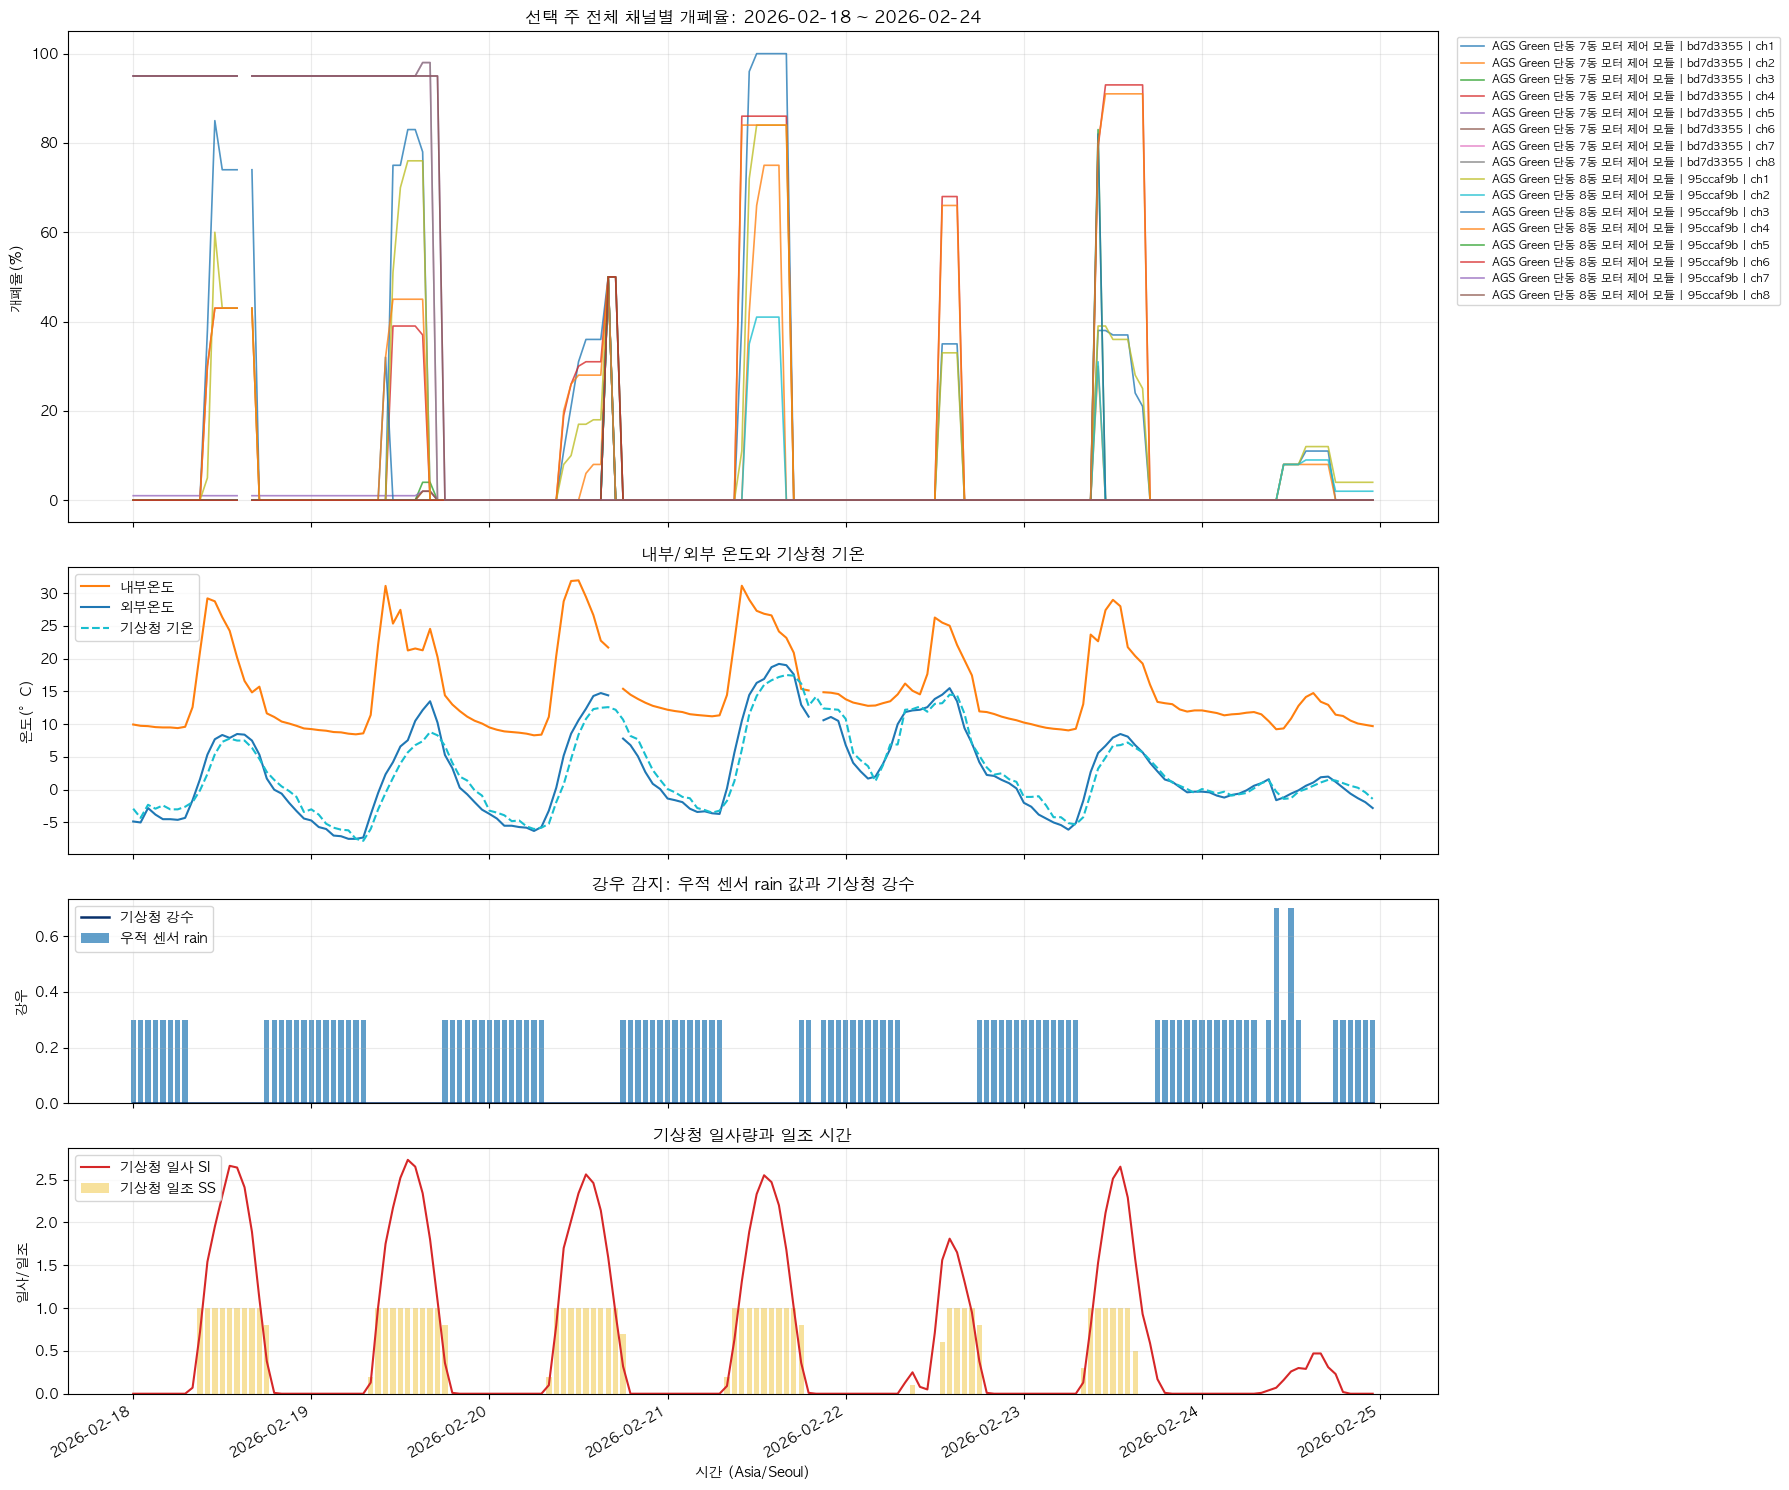

## 상관관계 상위 항목

,motor_channel,weather_variable,n,pearson,spearman,abs_pearson
6,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,kma_solar_radiation,167,0.841814,0.769799,0.841814
116,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch4,kma_solar_radiation,167,0.811119,0.749026,0.811119
86,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch1,kma_solar_radiation,167,0.809433,0.729202,0.809433
36,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,kma_solar_radiation,167,0.792812,0.738234,0.792812
110,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch4,internal_temp,165,0.729490,0.676214,0.729490
30,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,internal_temp,165,0.710051,0.659917,0.710051
0,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,internal_temp,165,0.678293,0.637045,0.678293
5,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,kma_sunshine,167,0.671912,0.656286,0.671912
115,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch4,kma_sunshine,167,0.656936,0.727743,0.656936
35,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,kma_sunshine,167,0.639776,0.713878,0.639776


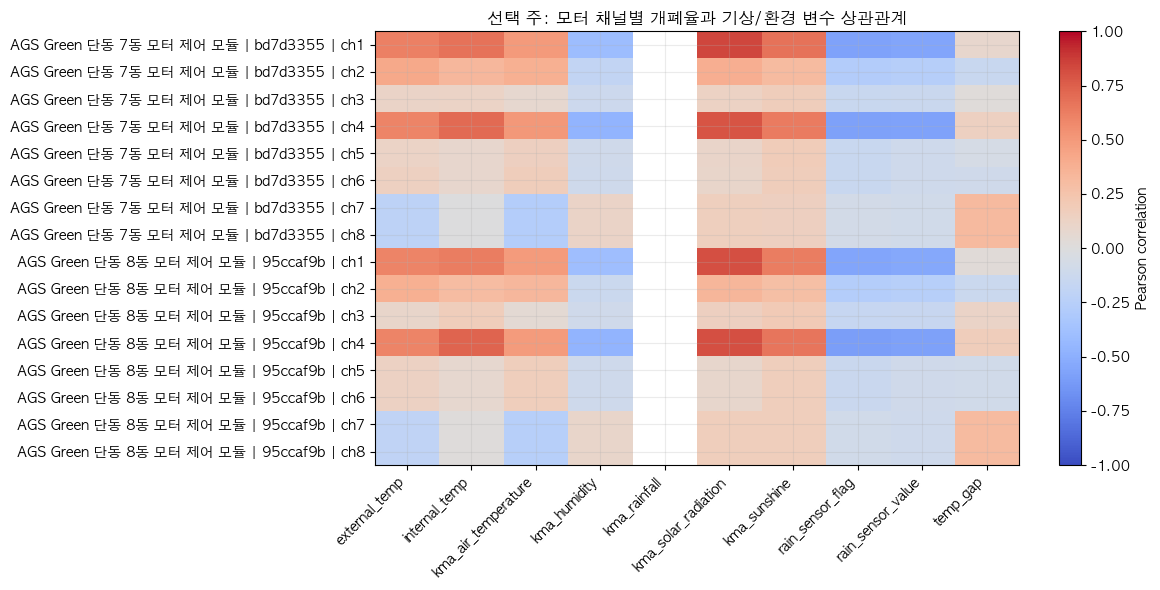

## 날짜별 현상 요약

,date,max_open_rate,peak_open_rate_time,peak_open_rate_channel,active_channel_count,channel_max_open_rates,internal_temp_max,external_temp_max,temp_gap_max,rain_sensor_hours,kma_rain_hours,kma_sunshine_sum,kma_solar_radiation_sum,phenomenon_note
0,2026-02-18,95.0,2026-02-18 00:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch7,8,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1: 85....,29.200,8.50,23.850,14,0,9.8,17.69,"강우 감지, 일사/일조 관측, 개별 채널 개폐율 높음, 내부-외부 온도차 큼"
1,2026-02-19,98.0,2026-02-19 15:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch7,9,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1: 83....,31.100,13.50,28.750,14,0,10.0,18.56,"강우 감지, 일사/일조 관측, 개별 채널 개폐율 높음, 내부-외부 온도차 큼"
2,2026-02-20,50.0,2026-02-20 16:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,12,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1: 50....,31.950,14.75,23.550,14,0,9.9,16.96,"강우 감지, 일사/일조 관측, 내부-외부 온도차 큼"
3,2026-02-21,100.0,2026-02-21 12:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1,6,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1: 100...,31.125,19.20,20.625,13,0,10.0,16.52,"강우 감지, 일사/일조 관측, 개별 채널 개폐율 높음, 내부-외부 온도차 큼"
4,2026-02-22,68.0,2026-02-22 13:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,4,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1: 35....,26.275,15.50,12.425,14,0,5.5,8.89,"강우 감지, 일사/일조 관측, 개별 채널 개폐율 높음, 내부-외부 온도차 큼"
5,2026-02-23,93.0,2026-02-23 11:00:00+09:00,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch4,8,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1: 38....,28.975,8.50,21.025,14,0,6.8,15.28,"강우 감지, 일사/일조 관측, 개별 채널 개폐율 높음, 내부-외부 온도차 큼"
6,2026-02-24,12.0,2026-02-24 14:00:00+09:00,AGS Green 단동 8동 모터 제어 모듈 | 95ccaf9b | ch1,4,AGS Green 단동 7동 모터 제어 모듈 | bd7d3355 | ch1: 11....,14.750,2.00,13.650,19,0,0.0,2.63,"강우 감지, 일사/일조 관측, 내부-외부 온도차 큼"


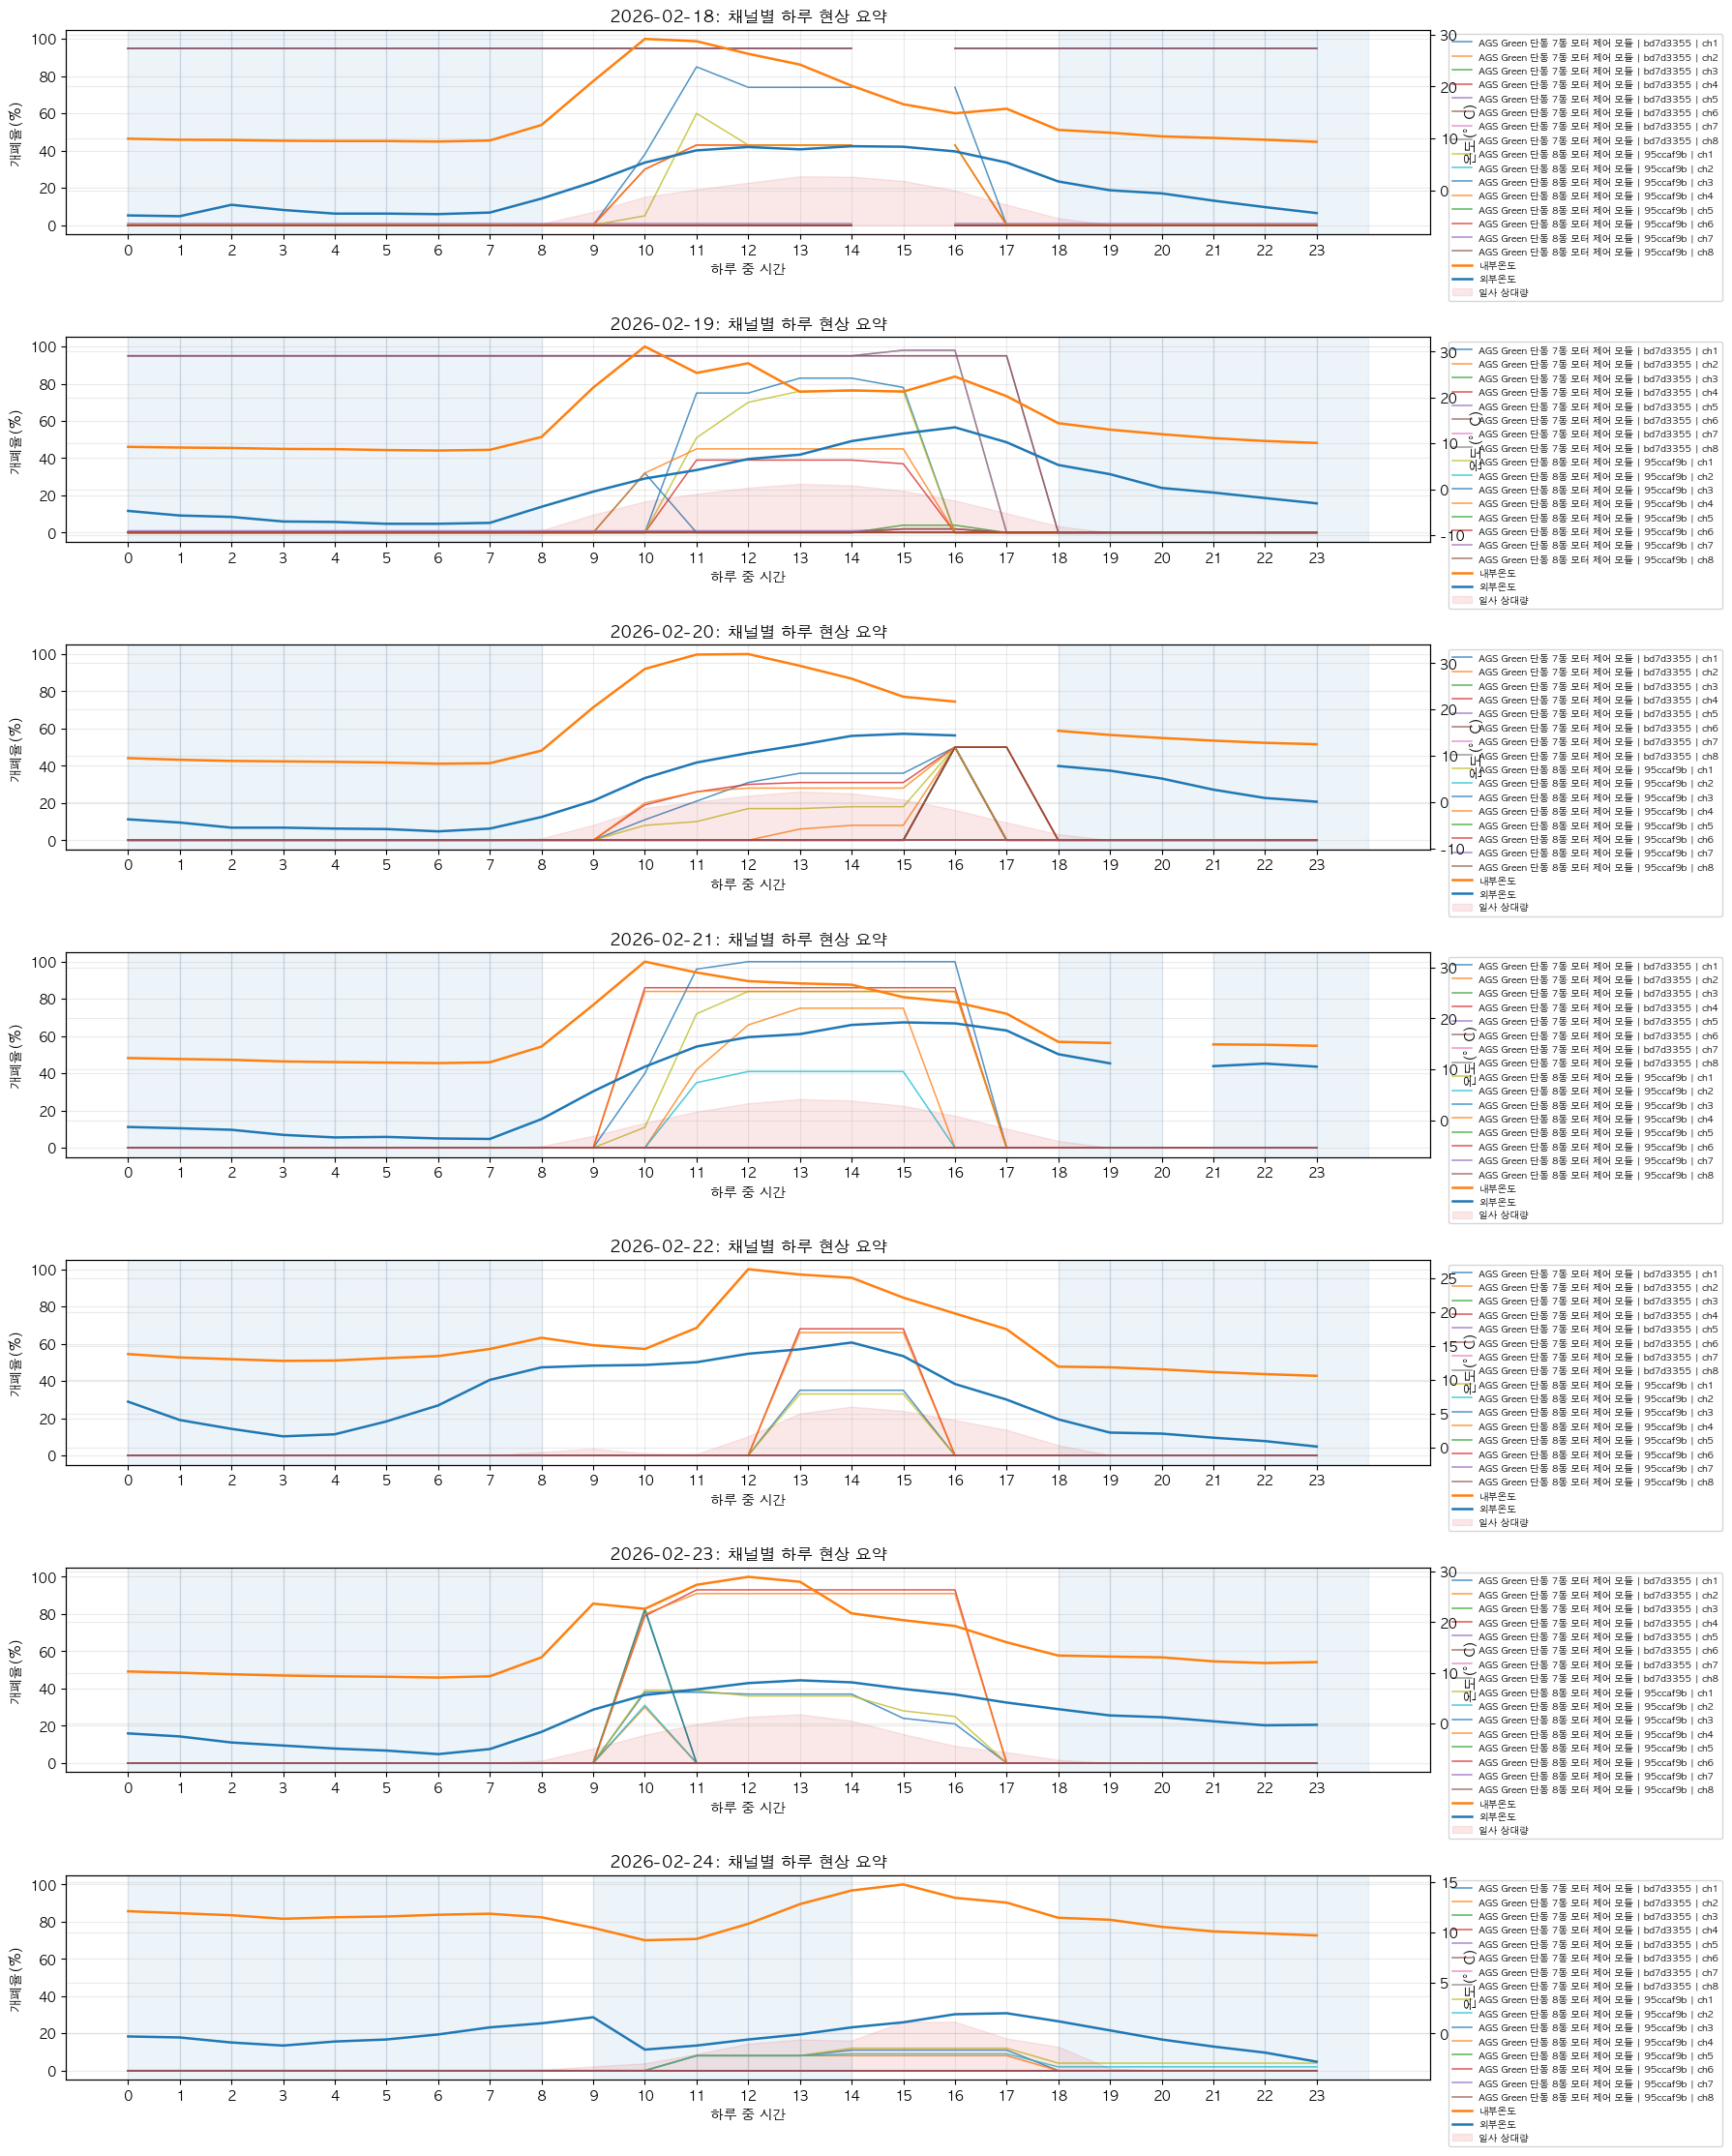

In [35]:
week_result = analyze_week(
    week_index=SELECTED_WEEK_INDEX,
    week_start_date=SELECTED_WEEK_START_DATE,
    save_outputs=SAVE_WEEK_OUTPUTS,
)

## 7. 선택 위젯으로 주 변경하기

`ipywidgets`가 설치되어 있으면 드롭다운과 버튼으로 주를 바꿔 분석할 수 있다.

위젯이 보이지 않거나 동작하지 않으면, 앞의 `SELECTED_WEEK_INDEX` 값을 직접 바꾸는 방식으로 사용하면 된다.

In [36]:
try:
    import ipywidgets as widgets

    week_options = [
        (f"{int(row.week_index):02d}: {row.week_start:%Y-%m-%d} ~ {row.week_end:%Y-%m-%d}", int(row.week_index))
        for row in week_table.itertuples(index=False)
    ]
    dropdown = widgets.Dropdown(options=week_options, value=SELECTED_WEEK_INDEX, description="주 선택")
    button = widgets.Button(description="선택 주 분석 실행", button_style="primary")
    output = widgets.Output()

    def run_selected_week(_):
        with output:
            clear_output(wait=True)
            analyze_week(week_index=dropdown.value, save_outputs=SAVE_WEEK_OUTPUTS)

    button.on_click(run_selected_week)
    display(widgets.HBox([dropdown, button]))
    display(output)
except Exception as exc:
    display(Markdown(f"ipywidgets를 사용할 수 없어 변수 설정 방식으로 사용한다: `{exc}`"))

ipywidgets를 사용할 수 없어 변수 설정 방식으로 사용한다: `No module named 'ipywidgets'`

## 8. 결과 파일 구조

기본 출력 폴더는 다음과 같다.

`data_inspect/output/weekly_motor_weather_analysis_260211-260511/`

공통 파일:

- `aligned_hourly_all.csv`: 전체 기간 1시간 정렬 데이터
- `available_weeks.csv`: 선택 가능한 주 목록

선택 주별 폴더:

- `week_00_20260210/` 같은 형식의 폴더
- `week_aligned_hourly.csv`: 선택 주의 정렬 데이터
- `week_correlations.csv`: 선택 주 상관관계 표
- `week_daily_summary.csv`: 선택 주 날짜별 현상 요약
- `week_overview_open_rate_temperature_rain_solar.png`: 주간 통합 그래프
- `week_correlation_heatmap.png`: 상관관계 heatmap
- `daily_phenomena_profiles.png`: 하루별 현상 그래프

## 해석 시 주의사항

- 우적 센서의 `rain`은 `0`이면 맑음/비감지, `0`보다 크면 강우 감지로 해석했다.
- 기상청 `SS`, `SI`의 음수 sentinel 값은 시각화와 집계를 위해 `0`으로 처리했다.
- KMA 시각은 한국 시간 기준 관측값으로 간주했다.
- 선택한 1주 구간이 전체 주와 완전히 일치하지 않는 첫 주/마지막 주는 데이터 시간이 168시간보다 적을 수 있다.
- 상관관계는 같은 시간대의 1시간 집계값 기준이다. 제어 반응 지연을 엄밀히 보려면 lag 상관분석을 추가로 수행하는 것이 좋다.